In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'plots', 'README.md', 'Task1_Analysis.ipynb', 'Train.csv']


In [2]:
print(os.getcwd())

C:\Users\stark\DevRise-Task1


In [3]:
print(os.listdir())

['.ipynb_checkpoints', 'plots', 'README.md', 'Task1_Analysis.ipynb', 'Train.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [6]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

## Data Cleaning

We found missing values in two columns:
- Item_Weight: 1463 missing (numerical) — will fill with median
- Outlet_Size: 2410 missing (categorical) — will fill with mode

In [7]:
df_clean = df.copy()

# Item_Weight (numerical) -> fill with median
df_clean['Item_Weight'] = df_clean['Item_Weight'].fillna(df_clean['Item_Weight'].median())

# Outlet_Size (categorical) -> fill with mode
df_clean['Outlet_Size'] = df_clean['Outlet_Size'].fillna(df_clean['Outlet_Size'].mode()[0])

# Confirm no missing values remain
print(df_clean.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [8]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows:", duplicate_count)
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows: 0
Shape after removing duplicates: (8523, 12)


## Fixing Data Types and Anomalies

- Converting categorical columns to proper category dtype
- Item_Visibility has 0.000000 values which is unrealistic (a product can't have zero visibility if it sold) — treating as anomaly and replacing with mean visibility for that item type

In [9]:
# Fix data types
df_clean['Item_Fat_Content'] = df_clean['Item_Fat_Content'].astype('category')
df_clean['Item_Type'] = df_clean['Item_Type'].astype('category')
df_clean['Outlet_Size'] = df_clean['Outlet_Size'].astype('category')
df_clean['Outlet_Location_Type'] = df_clean['Outlet_Location_Type'].astype('category')
df_clean['Outlet_Type'] = df_clean['Outlet_Type'].astype('category')

# Fix anomaly: Item_Visibility = 0 is unrealistic, replace with mean visibility per Item_Type
zero_vis_count = (df_clean['Item_Visibility'] == 0).sum()
print("Rows with zero visibility:", zero_vis_count)

df_clean['Item_Visibility'] = df_clean.groupby('Item_Type', observed=True)['Item_Visibility'].transform(
    lambda x: x.replace(0, x.mean())
)

print("Rows with zero visibility after fix:", (df_clean['Item_Visibility'] == 0).sum())
df_clean.dtypes

Rows with zero visibility: 526
Rows with zero visibility after fix: 0


Item_Identifier                   str
Item_Weight                   float64
Item_Fat_Content             category
Item_Visibility               float64
Item_Type                    category
Item_MRP                      float64
Outlet_Identifier                 str
Outlet_Establishment_Year       int64
Outlet_Size                  category
Outlet_Location_Type         category
Outlet_Type                  category
Item_Outlet_Sales             float64
dtype: object

In [10]:
df_clean['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [11]:
df_clean['Item_Fat_Content'] = df_clean['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})
df_clean['Item_Fat_Content'] = df_clean['Item_Fat_Content'].astype('category')
df_clean['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
LF            0
low fat       0
reg           0
Name: count, dtype: int64

## Descriptive Statistics

Summary statistics for numerical and categorical features after cleaning.


In [12]:
df_clean.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.00000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.81342,0.070208,140.992782,1997.831867,2181.288914
std,4.22724,0.048754,62.275067,8.371760,1706.499616
min,4.55500,0.003575,31.290000,1985.000000,33.290000
25%,9.31000,0.033085,93.826500,1987.000000,834.247400
50%,12.60000,0.061322,143.012800,1999.000000,1794.331000
75%,16.00000,0.094585,185.643700,2004.000000,3101.296400
max,21.35000,0.328391,266.888400,2009.000000,13086.964800


In [13]:
sales_arr = df_clean['Item_Outlet_Sales'].to_numpy()
mrp_arr = df_clean['Item_MRP'].to_numpy()

print("Average Sales:", np.mean(sales_arr))
print("Median Sales:", np.median(sales_arr))
print("Std Dev of Sales:", np.std(sales_arr))
print("Average MRP:", np.mean(mrp_arr))
print("Max Sales:", np.max(sales_arr))
print("Min Sales:", np.min(sales_arr))

Average Sales: 2181.288913575032
Median Sales: 1794.331
Std Dev of Sales: 1706.3995013565952
Average MRP: 140.9927819781767
Max Sales: 13086.9648
Min Sales: 33.29


In [14]:
avg_sales_by_outlet_type = df_clean.groupby('Outlet_Type', observed=True)['Item_Outlet_Sales'].mean().sort_values(ascending=False)
print("Average Sales by Outlet Type:\n", avg_sales_by_outlet_type)

avg_sales_by_size = df_clean.groupby('Outlet_Size', observed=True)['Item_Outlet_Sales'].mean().sort_values(ascending=False)
print("\nAverage Sales by Outlet Size:\n", avg_sales_by_size)

Average Sales by Outlet Type:
 Outlet_Type
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: Item_Outlet_Sales, dtype: float64

Average Sales by Outlet Size:
 Outlet_Size
High      2298.995256
Medium    2283.730470
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64


In [15]:
import os
os.makedirs('plots', exist_ok=True)

## Visualizations


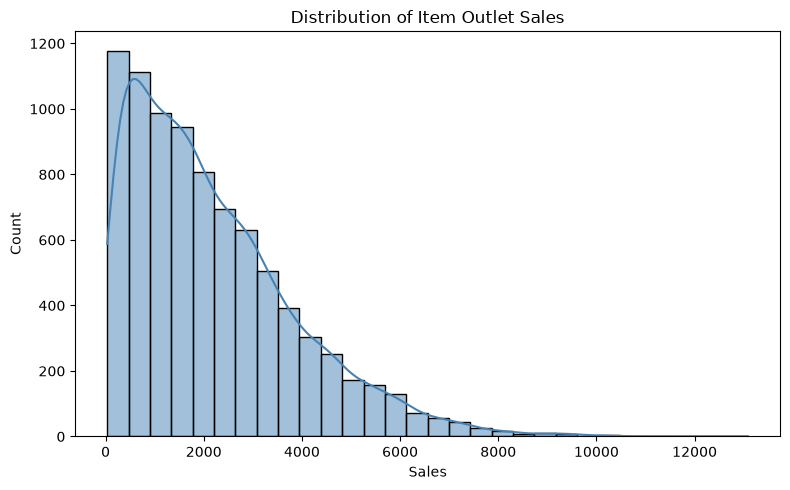

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Item_Outlet_Sales'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/sales_distribution.png', dpi=300)
plt.show()

C:\Users\stark\AppData\Local\Temp\ipykernel_6252\2465279738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sales_by_outlet_type.index, y=avg_sales_by_outlet_type.values, palette='viridis')


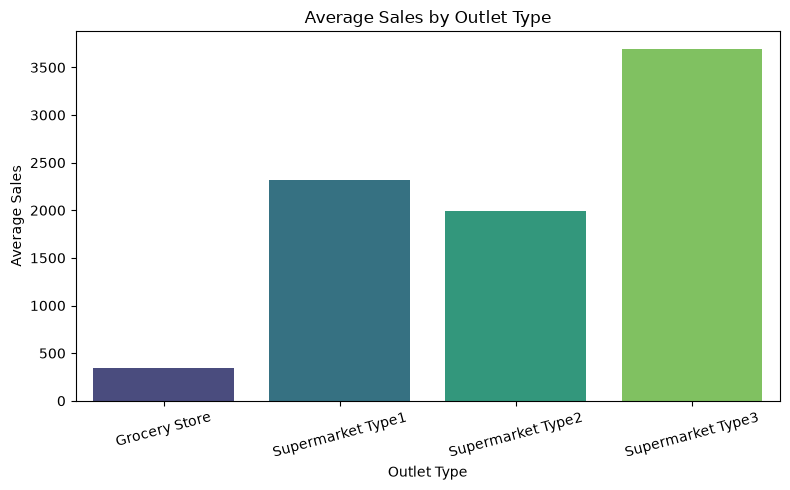

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg_sales_by_outlet_type.index, y=avg_sales_by_outlet_type.values, palette='viridis')
plt.title('Average Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plots/avg_sales_by_outlet_type.png', dpi=300)
plt.show()

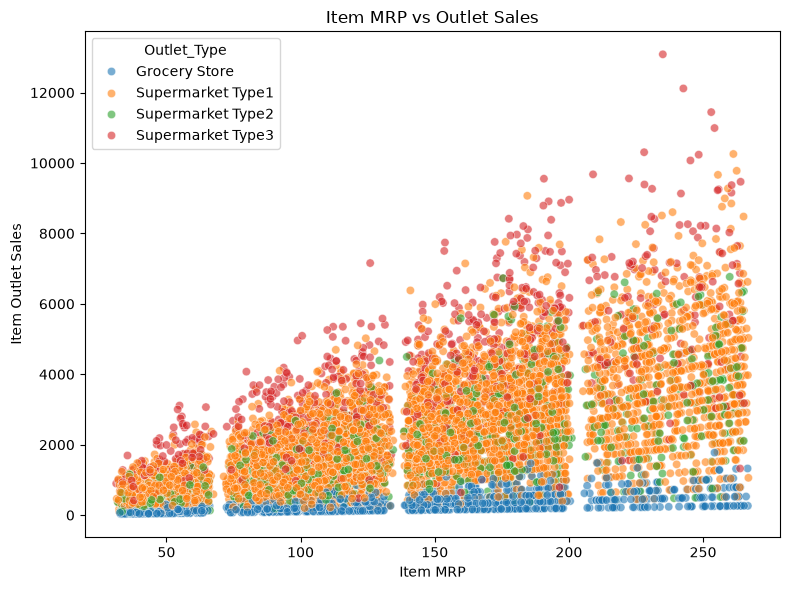

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='Item_MRP', y='Item_Outlet_Sales', hue='Outlet_Type', alpha=0.6)
plt.title('Item MRP vs Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.savefig('plots/mrp_vs_sales.png', dpi=300)
plt.show()

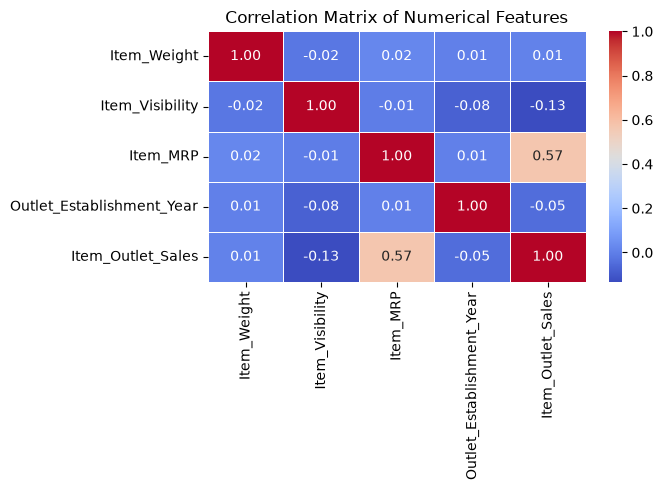

In [19]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=300)
plt.show()

## Business Insights

- **Item MRP is the strongest driver of sales**: correlation of 0.57 between Item_MRP and Item_Outlet_Sales — higher-priced items generate more revenue per unit.
- **Outlet Type matters more than Outlet Size**: Supermarket Type3 outlets average ~3694 in sales vs. Grocery Stores at ~340 — over 10x difference. Outlet Size (High/Medium/Small) shows much smaller variation.
- **Sales distribution is right-skewed**: most items sell in the 0-4000 range, with a long tail of high-selling outliers.
- **Data quality issues found and fixed**: inconsistent Item_Fat_Content labels (LF, low fat, reg) were standardized, missing Item_Weight and Outlet_Size values were imputed, and unrealistic zero-visibility entries were corrected using item-type averages.

## Conclusion

This analysis followed a complete data science pipeline: cleaning (missing values, duplicates, inconsistent categories, anomalies), descriptive statistics using Pandas/NumPy, and visual analysis using Matplotlib/Seaborn — revealing that outlet type and item pricing are the key levers behind sales performance.